In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import chi2
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import statsmodels.api as sm
import joblib
import sys

sys.modules['sklearn.externals.joblib'] = joblib
from mlxtend.feature_selection import SequentialFeatureSelector

In [3]:
from google.colab import files
uploaded = files.upload()

Saving clustered.csv to clustered.csv


In [4]:
df = pd.read_csv("clustered.csv")
df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_encoded,day_encoded,labels
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,7,0,1
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,10,5,0
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,10,2,0
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,7,0,1
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,7,3,1


In [5]:
corr=df.corr()
y = df['labels']
df.drop("labels",axis=1,inplace=True)

In [6]:
mms = MinMaxScaler()
mms.fit(df)
mmsdf = mms.transform(df)
x_train,x_test,y_train,y_test = train_test_split(mmsdf,y,test_size=0.2)
df=pd.DataFrame(mmsdf,columns =['X', 'Y', 'FFMC','DMC', 'DC', 'ISI','temp', 'RH', 'wind','rain', 'area', 'month_encoded','day_encoded'])

In [7]:
df.head()


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_encoded,day_encoded
0,0.750,0.428571,0.870968,0.086492,0.101325,0.090909,0.192926,0.423529,0.700000,0.00000,0.0,0.636364,0.000000
1,0.750,0.285714,0.927742,0.118194,0.775419,0.119430,0.508039,0.211765,0.055556,0.00000,0.0,0.909091,0.833333
2,0.750,0.285714,0.927742,0.146795,0.796294,0.119430,0.398714,0.211765,0.100000,0.00000,0.0,0.909091,0.333333
3,0.875,0.571429,0.941935,0.110958,0.081623,0.160428,0.196141,0.964706,0.400000,0.03125,0.0,0.636364,0.000000
4,0.875,0.571429,0.910968,0.172984,0.110590,0.171123,0.295820,0.988235,0.155556,0.00000,0.0,0.636364,0.500000


[0.01237765 0.00920513 0.06510273 0.1837986  0.38729164 0.05705535
 0.12991387 0.02347968 0.02148134 0.00093765 0.00972631 0.08294795
 0.0166821 ]


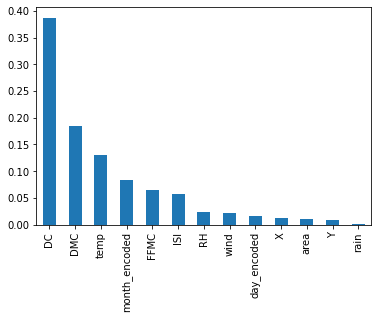

In [8]:
etc = ExtraTreesClassifier()
etc.fit(df, y)
print(etc.feature_importances_)
feat_importances = pd.Series(etc.feature_importances_, index=df.columns)
feat_importances.nlargest(13).plot.bar()
plt.show()

list1=feat_importances.keys().to_list()

In [9]:
forward_feature_selector = SequentialFeatureSelector(RandomForestClassifier(n_jobs=-1),
           k_features=6,
           forward=True,
           verbose=2,
           scoring='roc_auc',
           cv=4)
           
fselector = forward_feature_selector.fit(df,y)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:   24.1s finished

[2023-03-15 18:39:46] Features: 1/6 -- score: 0.9755757575757577[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:   10.8s finished

[2023-03-15 18:39:56] Features: 2/6 -- score: 0.9948392255892256[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    8.6s finished

[2023-03-15 18:40:05] Features: 3/6 -- score: 0.997983164983165[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 o

In [10]:
fward=fselector.k_feature_names_
list2=list(fward)
list2

['FFMC', 'DC', 'temp', 'wind', 'rain', 'area']

In [11]:
chi2_features = SelectKBest(chi2, k = 6) 
X_kbest_features = chi2_features.fit_transform(df, y)
mask=chi2_features.get_support()
new_feature=[]
for bool,feature in zip(mask,df.columns):
  if bool:
    new_feature.append(feature)
list3=new_feature
list3

['DMC', 'DC', 'ISI', 'temp', 'wind', 'day_encoded']

In [12]:
#Correlation with output variable
cor_target = abs(corr["area"])
#Selecting highly correlated features
relevant_features = cor_target[cor_target>0.05]
list4=relevant_features.keys().to_list()
list4

['X', 'DMC', 'temp', 'RH', 'area', 'labels']

In [13]:
my_array = np.array(y)

y = pd.DataFrame(my_array, columns = ['area'])

In [ ]:
print(type(y))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [33]:
final_list=[list1,list2,list3,list4]
name=['Extra_Tree_Classifier','Forward_Selection','CHI-square','Pearson Correlation']
dflist=pd.DataFrame(list(zip(name,final_list)),columns=['Name','Features'])
dflist
# from google.colab import files
# dflist.to_csv('dflist.csv') 
# files.download('dflist.csv')

,Name,Features
0,Extra_Tree_Classifier,"[X, Y, FFMC, DMC, DC, ISI, temp, RH, wind, rai..."
1,Forward_Selection,"[FFMC, DC, temp, wind, rain, area]"
2,CHI-square,"[DMC, DC, ISI, temp, wind, day_encoded]"
3,Pearson Correlation,"[X, DMC, temp, RH, area, labels]"


In [15]:
feat=[]
feat= [value for value in list1 if value in list2 and value in list3 and value in list4 ]
feat

['temp']

In [ ]:
df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_encoded,day_encoded
0,0.750,0.428571,0.870968,0.086492,0.101325,0.090909,0.192926,0.423529,0.700000,0.00000,0.0,0.636364,0.000000
1,0.750,0.285714,0.927742,0.118194,0.775419,0.119430,0.508039,0.211765,0.055556,0.00000,0.0,0.909091,0.833333
2,0.750,0.285714,0.927742,0.146795,0.796294,0.119430,0.398714,0.211765,0.100000,0.00000,0.0,0.909091,0.333333
3,0.875,0.571429,0.941935,0.110958,0.081623,0.160428,0.196141,0.964706,0.400000,0.03125,0.0,0.636364,0.000000
4,0.875,0.571429,0.910968,0.172984,0.110590,0.171123,0.295820,0.988235,0.155556,0.00000,0.0,0.636364,0.500000


In [16]:
dffs = df[['temp']]
dffsf = df[['DMC', 'DC', 'temp','wind','area']]
dffsff = df[['X', 'Y','FFMC', 'DMC', 'DC', 'ISI', 'RH','temp', 'wind','area','day_encoded']]

x_train,x_test,y_train,y_test = train_test_split(df,y,test_size=0.2)
x_trainfs,x_testfs,y_trainfs,y_testfs = train_test_split(dffs,y,test_size=0.2)
x_trainfsf,x_testfsf,y_trainfsf,y_testfsf = train_test_split(dffsf,y,test_size=0.2)
x_trainfsff,x_testfsff,y_trainfsff,y_testfsff = train_test_split(dffsff,y,test_size=0.2)

trainX = [x_train, x_trainfs, x_trainfsf,x_trainfsff]
testX = [x_test, x_testfs, x_testfsf, x_testfsff]
trainY = [y_train, y_trainfs, y_trainfsf, y_trainfsff]
testY = [y_test, y_testfs, y_testfsf, y_testfsff]

# instantiate the model (using the default parameters)
logreg = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='linear')


In [34]:
accu=[]
for i in range(len(trainX)):
    
    # fit
    logreg.fit(trainX[i],trainY[i])
    # predict
    pred = logreg.predict(testX[i])
    # RMSE

    accu.append(metrics.accuracy_score(testY[i],pred))

# visualizing the result    
df_lr = pd.DataFrame({'Accuracy ':accu},index=['All','Four Threshold','Three Threshold','Two Threshold'])
df_lr
# from google.colab import files
# df_lr.to_csv('df_lr.csv') 
# files.download('df_lr.csv')

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

,Accuracy
All,0.961538
Four Threshold,0.865385
Three Threshold,0.971154
Two Threshold,0.980769


In [35]:
accu=[]
for i in range(len(trainX)):
    
    # fit
    knn.fit(trainX[i],trainY[i])
    # predict
    pred = knn.predict(testX[i])
    # RMSE

    accu.append(metrics.accuracy_score(testY[i],pred))

# visualizing the result    
df_knn = pd.DataFrame({'Accuracy ':accu},index=['All','Four Threshold','Three Threshold','Two Threshold'])
df_knn

/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

,Accuracy
All,0.961538
Four Threshold,0.923077
Three Threshold,0.980769
Two Threshold,0.971154


In [36]:
accu=[]
for i in range(len(trainX)):
    
    # fit
    svm.fit(trainX[i],trainY[i])
    # predict
    pred = svm.predict(testX[i])
    # RMSE

    accu.append(metrics.accuracy_score(testY[i],pred))

# visualizing the result    
df_svmfc = pd.DataFrame({'Accuracy ':accu},index=['All','Four Threshold','Three Threshold','Two Threshold'])
df_svmfc

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

,Accuracy
All,0.980769
Four Threshold,0.875000
Three Threshold,0.971154
Two Threshold,0.980769


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(df)
mmsdf = mms.transform(df)

sc = StandardScaler()
sc.fit(df)
scdf = sc.transform(df)

mms = MinMaxScaler()
mms.fit(dffsff)
mmsdfsff = mms.transform(dffsff)

sc = StandardScaler()
sc.fit(dffsff)
scdfsff = sc.transform(dffsff)

x_trainmmsfsf,x_testmmsfsf,y_trainmmsfsf,y_testmmsfsf = train_test_split(mmsdf,y,test_size=0.2)
x_trainscfsff,x_testscfsff,y_trainscfsff,y_testscfsff = train_test_split(scdf,y,test_size=0.2)
x_trainmmsfsff,x_testmmsfsff,y_trainmmsfsff,y_testmmsfsff = train_test_split(mmsdfsff,y,test_size=0.2)
x_trainscfsfff,x_testscfsfff,y_trainscfsfff,y_testscfsfff = train_test_split(scdfsff,y,test_size=0.2)

trainXX = [x_train, x_trainmmsfsf, x_trainscfsff,x_trainmmsfsff,x_trainscfsfff]
testXX = [x_test, x_testmmsfsf, x_testscfsff,x_testmmsfsff,x_testscfsfff]
trainYY = [y_train, y_trainmmsfsf, y_trainscfsff,y_trainmmsfsff,y_trainscfsfff]
testYY = [y_test, y_testmmsfsf, y_testscfsff,y_testmmsfsff,y_testscfsfff]

In [ ]:
accu=[]
for i in range(len(trainXX)):
    
    # fit
    knn.fit(trainXX[i],trainYY[i])
    # predict
    pred = knn.predict(testXX[i])
    # RMSE

    accu.append(metrics.accuracy_score(testYY[i],pred))

# visualizing the result    
df_knnfc = pd.DataFrame({'Accuracy ':accu},index=['All','MinMaxScaler','StandardScaler','MinMaxFeatureSelected','StandardFeatureSelected'])
df_knnfc

/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.9/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exam

,Accuracy
All,0.942308
MinMaxScaler,0.980769
StandardScaler,0.980769
MinMaxFeatureSelected,0.961538
StandardFeatureSelected,0.990385


In [ ]:
accu=[]
for i in range(len(trainXX)):
    
    # fit
    logreg.fit(trainXX[i],trainYY[i])
    # predict
    pred = logreg.predict(testXX[i])
    # RMSE

    accu.append(metrics.accuracy_score(testYY[i],pred))

# visualizing the result    
df_lrfs = pd.DataFrame({'Accuracy ':accu},index=['All','MinMaxScaler','StandardScaler','MinMaxFeatureSelected','StandardFeatureSelected'])
df_lrfs

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

,Accuracy
All,0.971154
MinMaxScaler,0.971154
StandardScaler,1.000000
MinMaxFeatureSelected,0.961538
StandardFeatureSelected,0.980769


In [ ]:
accu=[]
for i in range(len(trainXX)):
    
    # fit
    svm.fit(trainXX[i],trainYY[i])
    # predict
    pred = svm.predict(testXX[i])
    # RMSE

    accu.append(metrics.accuracy_score(testYY[i],pred))

# visualizing the result    
df_svmfs = pd.DataFrame({'Accuracy ':accu},index=['All','MinMaxScaler','StandardScaler','MinMaxFeatureSelected','StandardFeatureSelected'])
df_svmfs

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

,Accuracy
All,0.971154
MinMaxScaler,0.971154
StandardScaler,1.000000
MinMaxFeatureSelected,0.971154
StandardFeatureSelected,1.000000
